# 03 IndoBERT Sentiment Modeling

Executable reporting notebook for IndoBERT sentiment modeling. It runs only local dry-run validation, reads completed Colab experiment results, displays figures, and documents the current final candidate. It does not train or download models.


## CRISP-DM Stage

Modeling and Evaluation Preparation. Actual heavy fine-tuning is performed in Google Colab; this local notebook validates inputs and consolidates experiment results.


In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, Markdown, display


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "CLAUDE.md").exists() and (candidate / "ml-service").exists():
            return candidate
    raise RuntimeError("Could not find SentiRank project root from current working directory.")


PROJECT_ROOT = find_project_root()
ML_SERVICE_DIR = PROJECT_ROOT / "ml-service"
DATASETS_DIR = PROJECT_ROOT / "datasets"
DOCS_FIGURES_DIR = PROJECT_ROOT / "docs" / "figures"


def load_json(path: Path):
    if not path.exists():
        display(Markdown(f"Missing JSON: `{path.relative_to(PROJECT_ROOT)}`"))
        return None
    with path.open("r", encoding="utf-8") as file:
        return json.load(file)


def load_csv(path: Path, **kwargs):
    if not path.exists():
        display(Markdown(f"Missing CSV: `{path.relative_to(PROJECT_ROOT)}`"))
        return None
    return pd.read_csv(path, **kwargs)


def show_json_as_table(payload, title: str):
    if payload is None:
        return
    display(Markdown(f"### {title}"))
    try:
        table = pd.json_normalize(payload, sep=".").T.reset_index()
        table.columns = ["field", "value"]
        display(table)
    except Exception as exc:
        display(Markdown(f"Could not tabulate JSON payload: `{exc}`"))
        display(payload)


def show_csv_preview(path: Path, title: str, rows: int = 10):
    data = load_csv(path)
    if data is None:
        return None
    display(Markdown(f"### {title}"))
    display(data.head(rows))
    if len(data) > rows:
        display(Markdown(f"Rows: `{len(data)}`. Showing first `{rows}` rows."))
    return data


def show_figures(figure_paths: list[Path], title: str):
    display(Markdown(f"## {title}"))
    shown = 0
    for figure_path in figure_paths:
        if figure_path.exists():
            display(Markdown(f"**{figure_path.relative_to(PROJECT_ROOT)}**"))
            display(Image(filename=str(figure_path)))
            shown += 1
        else:
            display(Markdown(f"Missing figure: `{figure_path.relative_to(PROJECT_ROOT)}`"))
    if shown == 0:
        display(Markdown("No figures were available to display."))

print(f"Project root: {PROJECT_ROOT}")


Project root: C:\Data Central\Documents\Skripsi Ahmad Zaky Humami\Project Skripsi\SentiRank


## Safe Local Dry Run

This cell runs `train_indobert.py --dry-run` only. The dry run validates split files and configuration. It must not download model weights, train IndoBERT, or write model artifacts.


In [2]:
import subprocess
import sys

RUN_TRAIN_DRY_RUN = True
if RUN_TRAIN_DRY_RUN:
    command = [sys.executable, "scripts/train_indobert.py", "--dry-run"]
    result = subprocess.run(command, cwd=ML_SERVICE_DIR, text=True, capture_output=True, check=False)
    print(result.stdout)
    if result.stderr:
        print(result.stderr)
    print(f"Return code: {result.returncode}")
else:
    display(Markdown("Dry-run skipped. Full training is intentionally not included in this notebook."))


{
  "dataset_sizes": {
    "test": 14668,
    "train": 68446,
    "validation": 14668
  },
  "dry_run": true,
  "label_distribution": {
    "test": {
      "Negative": 5953,
      "Neutral": 2645,
      "Positive": 6070
    },
    "train": {
      "Negative": 27780,
      "Neutral": 12340,
      "Positive": 28326
    },
    "validation": {
      "Negative": 5953,
      "Neutral": 2644,
      "Positive": 6071
    }
  },
  "label_mapping": {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2
  },
  "planned_outputs": {
    "eval_metrics_figure": "..\\docs\\figures\\03_indobert\\indobert_eval_metrics.png",
    "metrics_output": "..\\datasets\\outputs\\eda\\03_indobert\\indobert_training_metrics.json",
    "model_dir": "saved_models\\indobert",
    "predictions_output": "..\\datasets\\outputs\\eda\\03_indobert\\indobert_test_predictions.csv",
    "training_loss_figure": "..\\docs\\figures\\03_indobert\\indobert_training_loss.png"
  },
  "side_effects": "No model download, no training, 

## Completed Experiment Runs

Run outputs are loaded from `datasets/outputs/eda/03_indobert/<run_name>/`. The current final IndoBERT candidate is `run_3_weighted_loss_lr_1e-5`.


In [3]:
EDA03_DIR = DATASETS_DIR / "outputs" / "eda" / "03_indobert"
RUNS = {
    "run_1_baseline": "Run 1 Baseline",
    "run_2_weighted_loss": "Run 2 Weighted Loss",
    "run_3_weighted_loss_lr_1e-5": "Run 3 Weighted Loss Lower LR",
    "run_4_weighted_loss_lr_1e-5_slang_norm": "Run 4 Slang Normalization",
}
FINAL_CANDIDATE = "run_3_weighted_loss_lr_1e-5"


def get_nested(payload: dict, *keys, default=None):
    current = payload
    for key in keys:
        if not isinstance(current, dict) or key not in current:
            return default
        current = current[key]
    return current


def load_run_payloads(run_name: str) -> dict:
    run_dir = EDA03_DIR / run_name
    return {
        "metrics": load_json(run_dir / "indobert_training_metrics.json"),
        "report": load_json(run_dir / "indobert_classification_report.json"),
        "comparison": load_json(run_dir / "indobert_run_comparison.json"),
    }

run_payloads = {run_name: load_run_payloads(run_name) for run_name in RUNS}
records = []
for run_name, run_label in RUNS.items():
    metrics = run_payloads[run_name]["metrics"] or {}
    report = run_payloads[run_name]["report"] or {}
    test_metrics = metrics.get("test_metrics", metrics)
    neutral = report.get("Neutral", {}) if isinstance(report, dict) else {}
    records.append({
        "run_name": run_name,
        "run_label": run_label,
        "accuracy": test_metrics.get("test_accuracy", report.get("accuracy") if isinstance(report, dict) else None),
        "macro_f1": test_metrics.get("test_f1_macro", get_nested(report, "macro avg", "f1-score")),
        "weighted_f1": test_metrics.get("test_f1_weighted", get_nested(report, "weighted avg", "f1-score")),
        "test_loss": test_metrics.get("test_loss"),
        "neutral_precision": neutral.get("precision"),
        "neutral_recall": neutral.get("recall"),
        "neutral_f1": neutral.get("f1-score"),
    })

comparison_df = pd.DataFrame(records)
display(comparison_df)


Missing JSON: `datasets\outputs\eda\03_indobert\run_1_baseline\indobert_run_comparison.json`

,run_name,run_label,accuracy,macro_f1,weighted_f1,test_loss,neutral_precision,neutral_recall,neutral_f1
0,run_1_baseline,Run 1 Baseline,0.741614,0.692673,0.736450,0.600660,0.563825,0.452552,0.502097
1,run_2_weighted_loss,Run 2 Weighted Loss,0.732820,0.703375,0.740310,0.680158,0.472370,0.636673,0.542351
2,run_3_weighted_loss_lr_1e-5,Run 3 Weighted Loss Lower LR,0.736229,0.709326,0.744468,0.665705,0.477015,0.666919,0.556204
3,run_4_weighted_loss_lr_1e-5_slang_norm,Run 4 Slang Normalization,0.732138,0.693988,0.736053,0.731941,0.475277,0.552363,0.510928


## Run Comparison Interpretation

Run 3 is selected as the current final candidate based on Macro F1, Weighted F1, Neutral F1, and the trade-off between Neutral recall and overall accuracy.


In [4]:
if comparison_df[["accuracy", "macro_f1", "weighted_f1", "neutral_f1"]].notna().any().any():
    metric_columns = ["accuracy", "macro_f1", "weighted_f1", "test_loss", "neutral_precision", "neutral_recall", "neutral_f1"]
    formatted = comparison_df.copy()
    for column in metric_columns:
        formatted[column] = formatted[column].map(lambda value: f"{value:.4f}" if pd.notna(value) else "missing")
    display(formatted)

    candidate_row = comparison_df.loc[comparison_df["run_name"] == FINAL_CANDIDATE]
    if not candidate_row.empty:
        row = candidate_row.iloc[0]
        notes = [
            f"Selected final IndoBERT candidate: `{FINAL_CANDIDATE}`.",
            f"Run 3 Macro F1: `{row['macro_f1']:.4f}` and Weighted F1: `{row['weighted_f1']:.4f}`.",
            f"Run 3 Neutral F1: `{row['neutral_f1']:.4f}` with Neutral recall `{row['neutral_recall']:.4f}`.",
        ]
        run2 = comparison_df.loc[comparison_df["run_name"] == "run_2_weighted_loss"]
        run4 = comparison_df.loc[comparison_df["run_name"] == "run_4_weighted_loss_lr_1e-5_slang_norm"]
        if not run2.empty:
            notes.append("Compared with Run 2, Run 3 improves the lower-learning-rate trade-off and keeps the weighted-loss benefit for Neutral.")
        if not run4.empty:
            run4_row = run4.iloc[0]
            if pd.notna(run4_row["macro_f1"]) and run4_row["macro_f1"] < row["macro_f1"]:
                notes.append("Run 4 slang normalization did not improve Macro F1 over Run 3, so it is not selected as the current final candidate.")
        notes.append("Model artifacts are stored outside Git; only small metrics and figures should be synchronized into the repository.")
        display(Markdown("\n".join(f"- {note}" for note in notes)))
else:
    display(Markdown("No run metrics are available in this checkout. Copy small Colab metrics into `datasets/outputs/eda/03_indobert/<run_name>/` and rerun this notebook."))


,run_name,run_label,accuracy,macro_f1,weighted_f1,test_loss,neutral_precision,neutral_recall,neutral_f1
0,run_1_baseline,Run 1 Baseline,0.7416,0.6927,0.7365,0.6007,0.5638,0.4526,0.5021
1,run_2_weighted_loss,Run 2 Weighted Loss,0.7328,0.7034,0.7403,0.6802,0.4724,0.6367,0.5424
2,run_3_weighted_loss_lr_1e-5,Run 3 Weighted Loss Lower LR,0.7362,0.7093,0.7445,0.6657,0.4770,0.6669,0.5562
3,run_4_weighted_loss_lr_1e-5_slang_norm,Run 4 Slang Normalization,0.7321,0.6940,0.7361,0.7319,0.4753,0.5524,0.5109


- Selected final IndoBERT candidate: `run_3_weighted_loss_lr_1e-5`.
- Run 3 Macro F1: `0.7093` and Weighted F1: `0.7445`.
- Run 3 Neutral F1: `0.5562` with Neutral recall `0.6669`.
- Compared with Run 2, Run 3 improves the lower-learning-rate trade-off and keeps the weighted-loss benefit for Neutral.
- Run 4 slang normalization did not improve Macro F1 over Run 3, so it is not selected as the current final candidate.
- Model artifacts are stored outside Git; only small metrics and figures should be synchronized into the repository.

## Experiment Figures

Figures are loaded from each run folder under `docs/figures/03_indobert/`.


## Run 1 Baseline

**docs\figures\03_indobert\run_1_baseline\indobert_confusion_matrix.png**

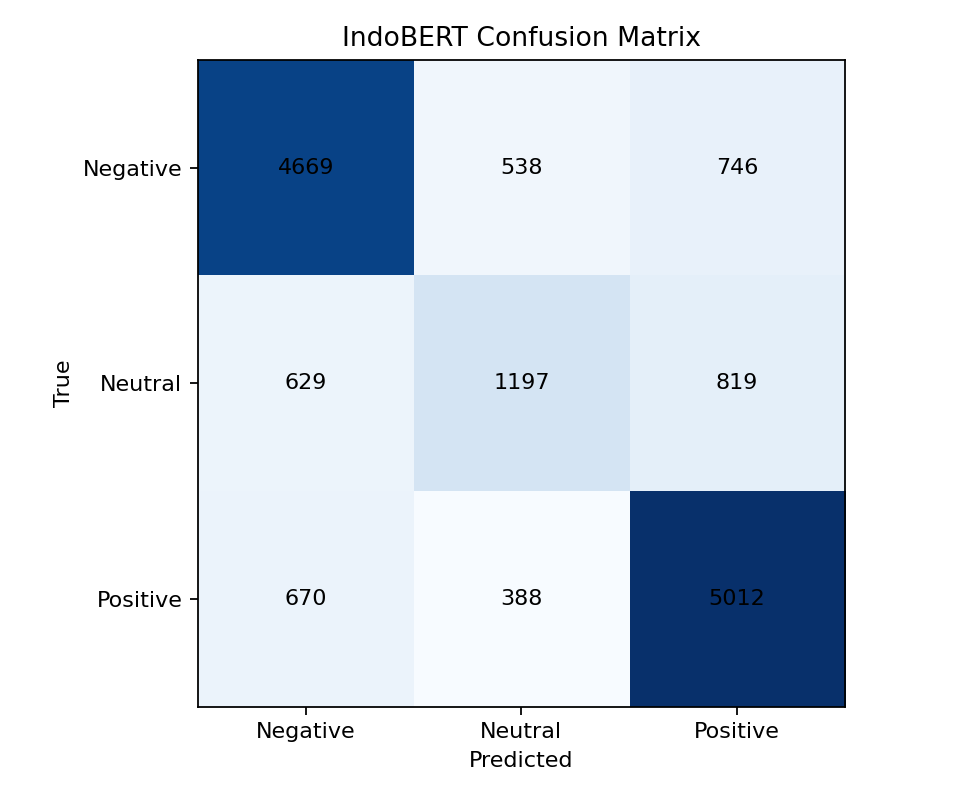

**docs\figures\03_indobert\run_1_baseline\indobert_eval_metrics.png**

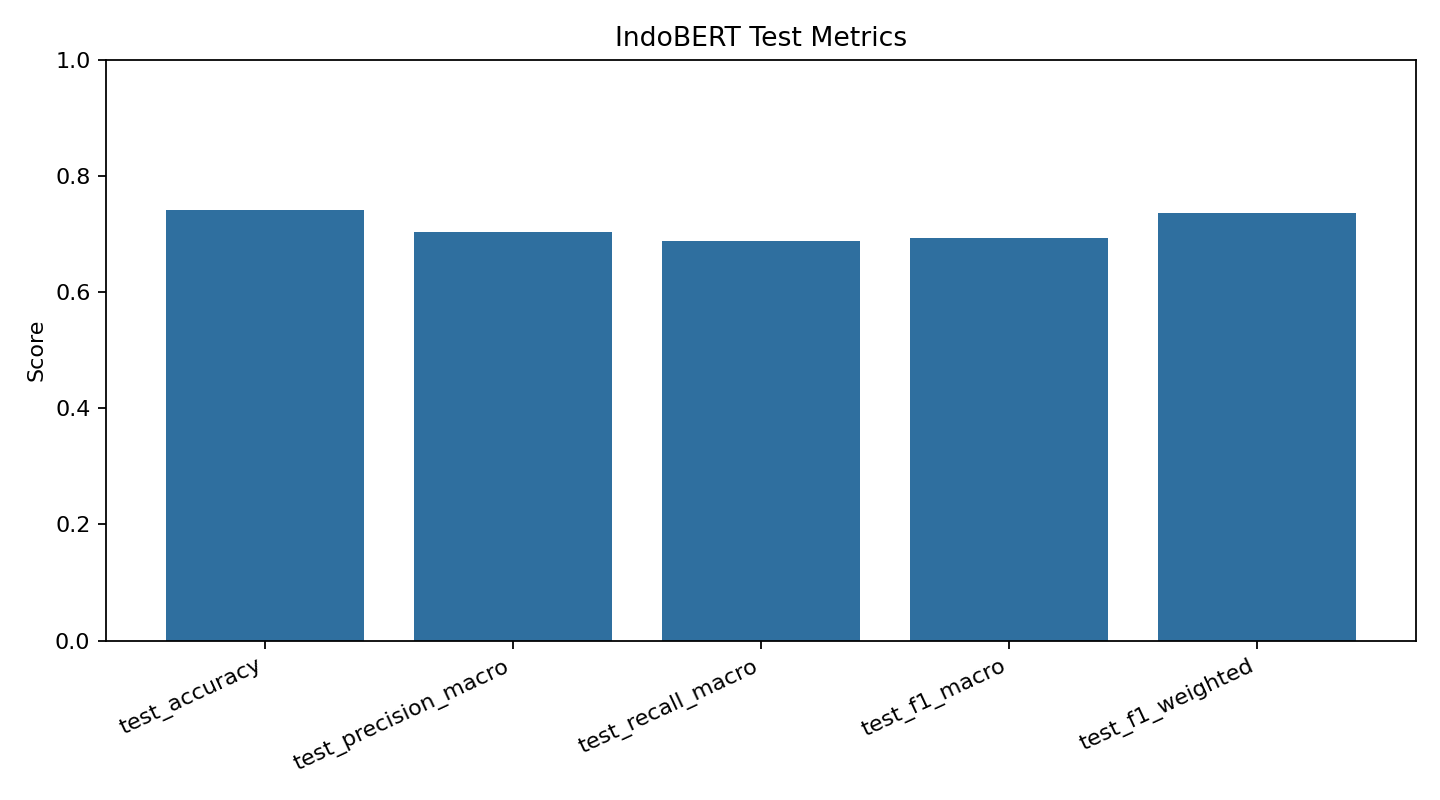

**docs\figures\03_indobert\run_1_baseline\indobert_training_loss.png**

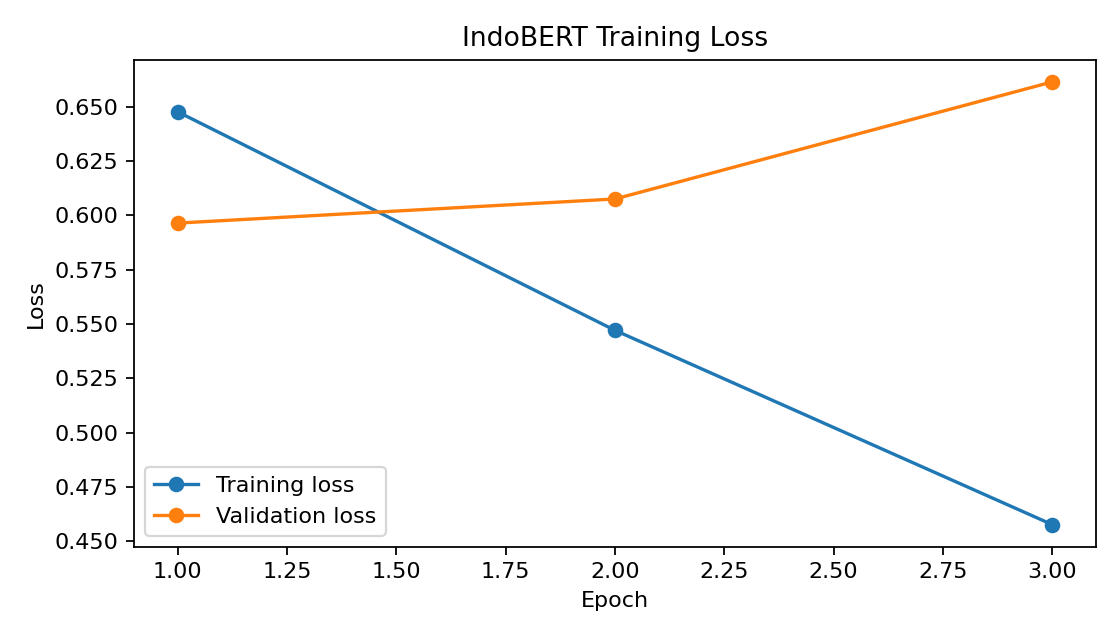

Missing figure: `docs\figures\03_indobert\run_1_baseline\indobert_class_f1_score.png`

Missing figure: `docs\figures\03_indobert\run_1_baseline\indobert_run_comparison.png`

Missing figure: `docs\figures\03_indobert\run_1_baseline\indobert_slang_changed_rows.png`

## Run 2 Weighted Loss

**docs\figures\03_indobert\run_2_weighted_loss\indobert_confusion_matrix.png**

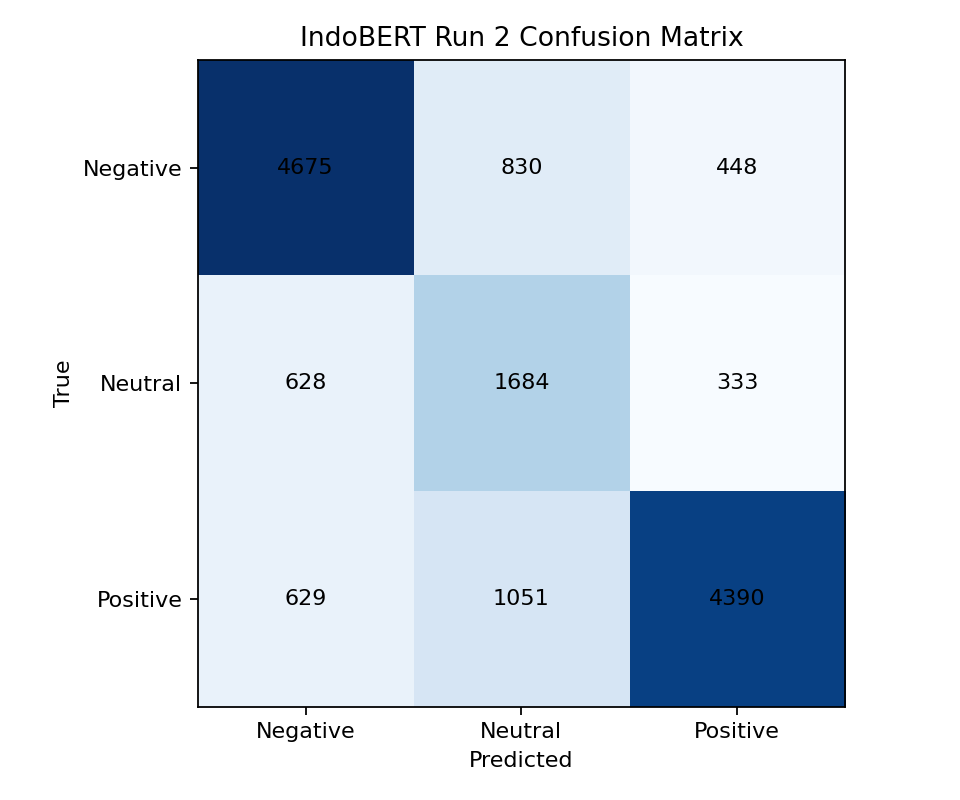

**docs\figures\03_indobert\run_2_weighted_loss\indobert_eval_metrics.png**

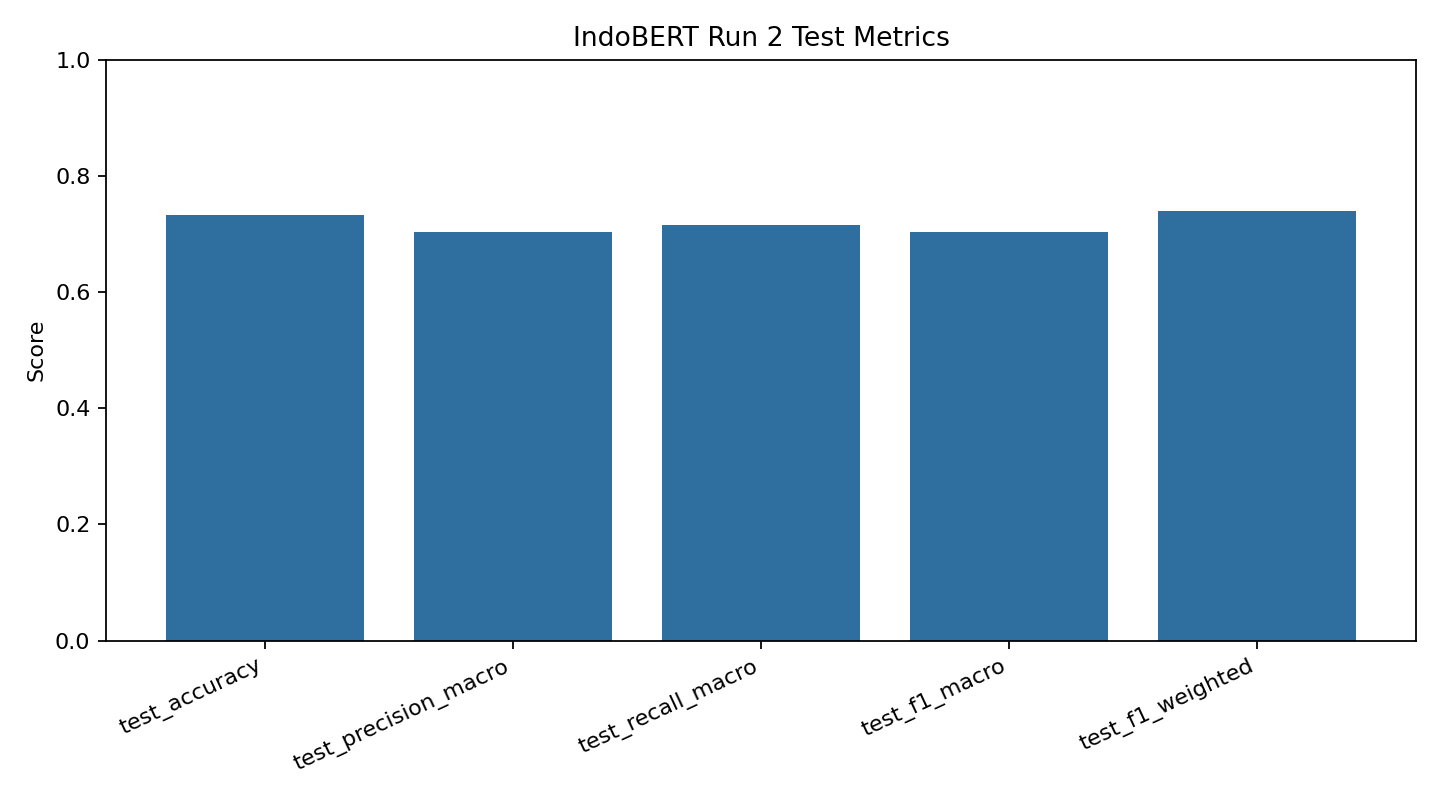

**docs\figures\03_indobert\run_2_weighted_loss\indobert_training_loss.png**

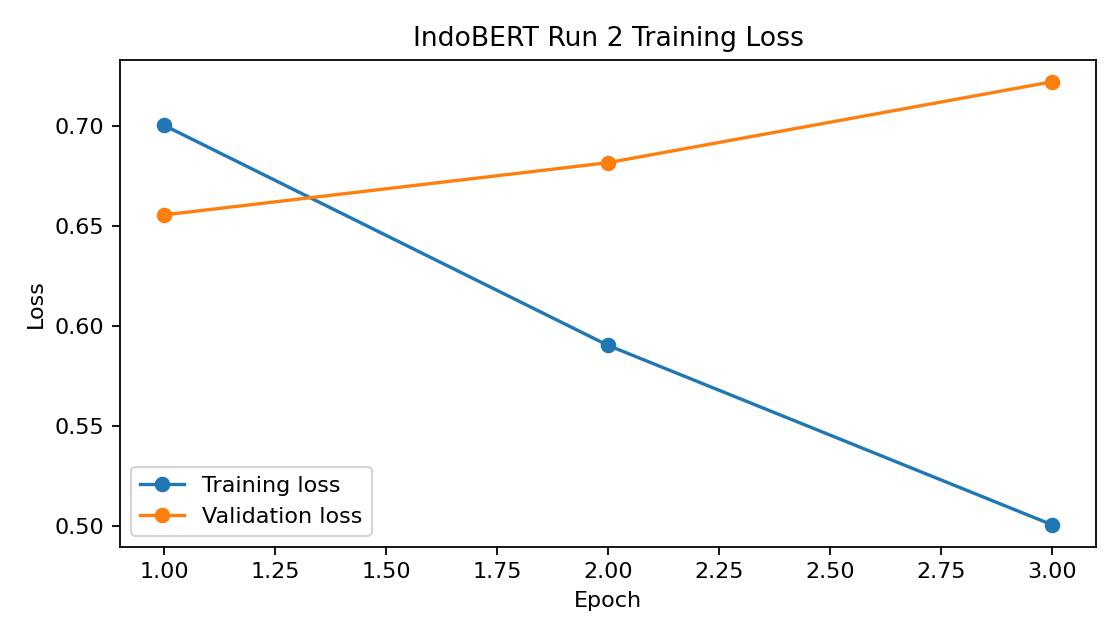

**docs\figures\03_indobert\run_2_weighted_loss\indobert_class_f1_score.png**

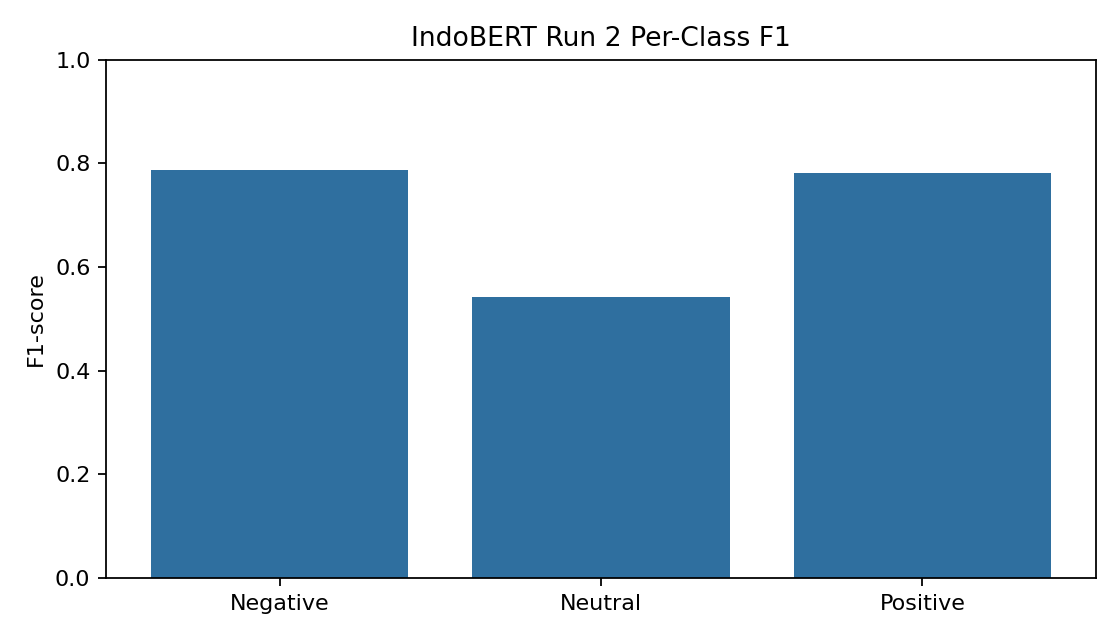

**docs\figures\03_indobert\run_2_weighted_loss\indobert_run_comparison.png**

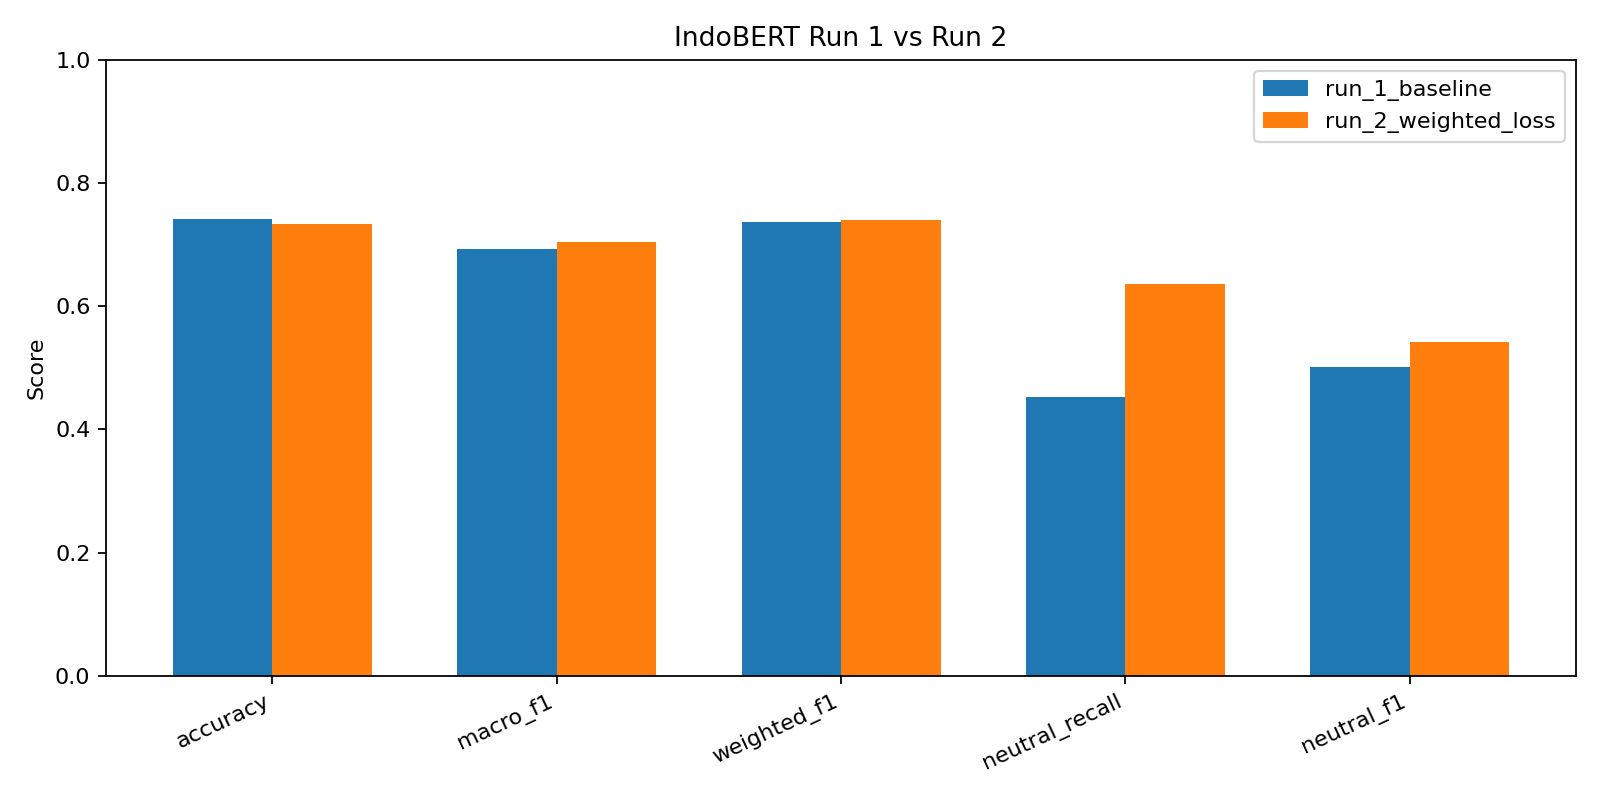

Missing figure: `docs\figures\03_indobert\run_2_weighted_loss\indobert_slang_changed_rows.png`

## Run 3 Weighted Loss Lower LR

**docs\figures\03_indobert\run_3_weighted_loss_lr_1e-5\indobert_confusion_matrix.png**

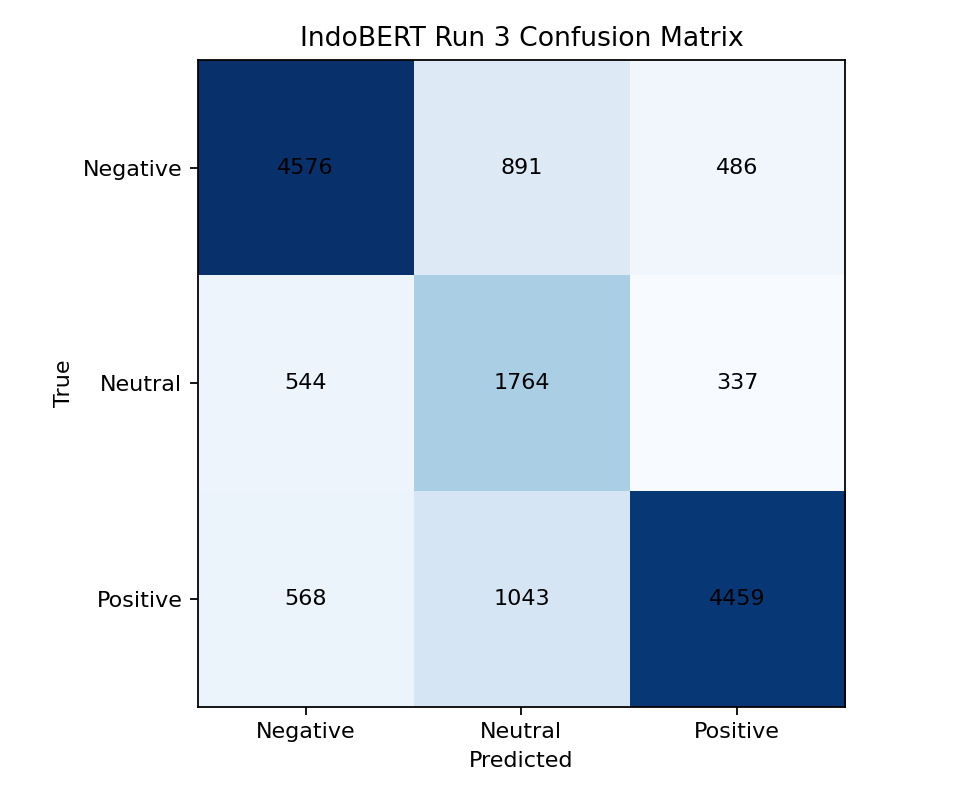

**docs\figures\03_indobert\run_3_weighted_loss_lr_1e-5\indobert_eval_metrics.png**

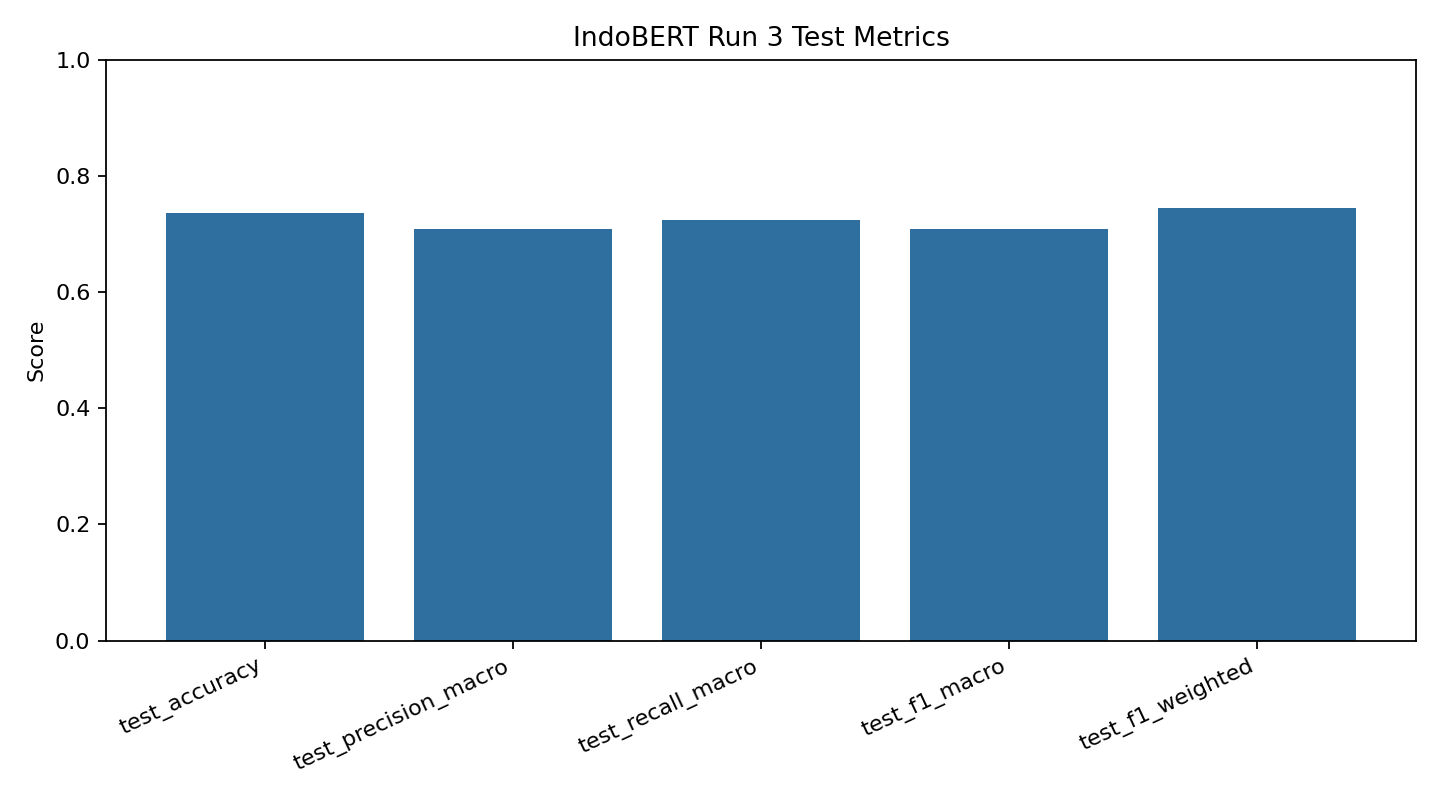

**docs\figures\03_indobert\run_3_weighted_loss_lr_1e-5\indobert_training_loss.png**

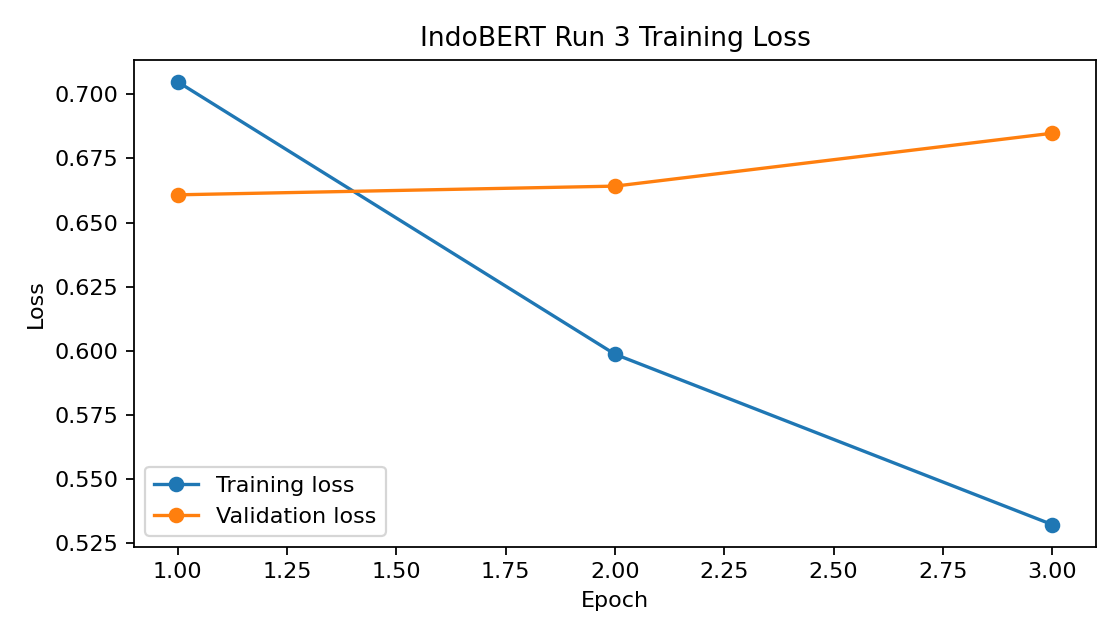

**docs\figures\03_indobert\run_3_weighted_loss_lr_1e-5\indobert_class_f1_score.png**

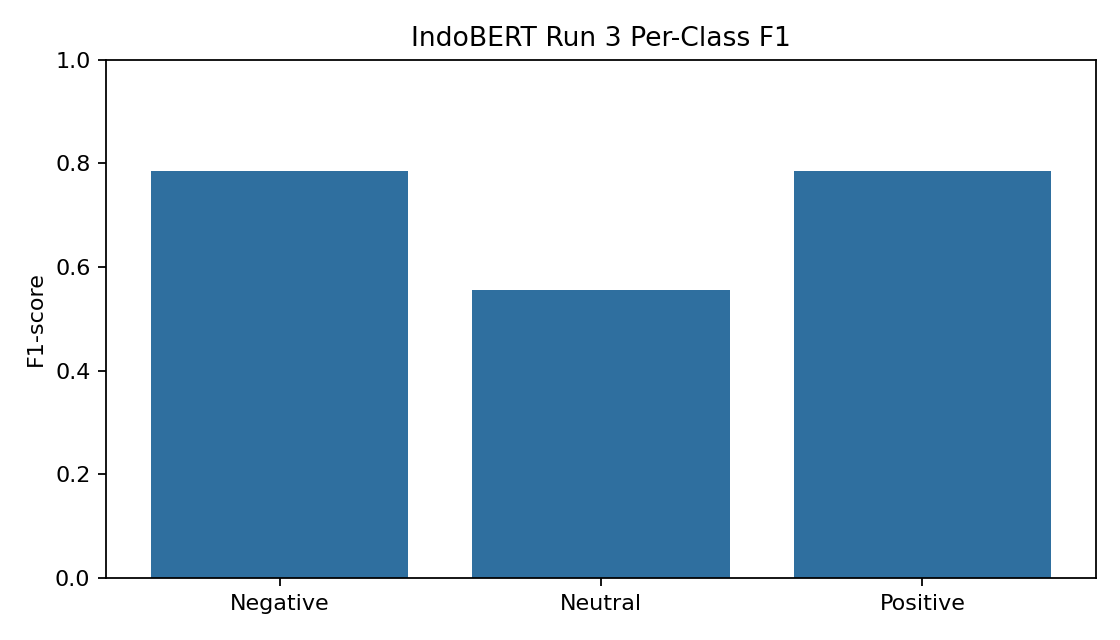

**docs\figures\03_indobert\run_3_weighted_loss_lr_1e-5\indobert_run_comparison.png**

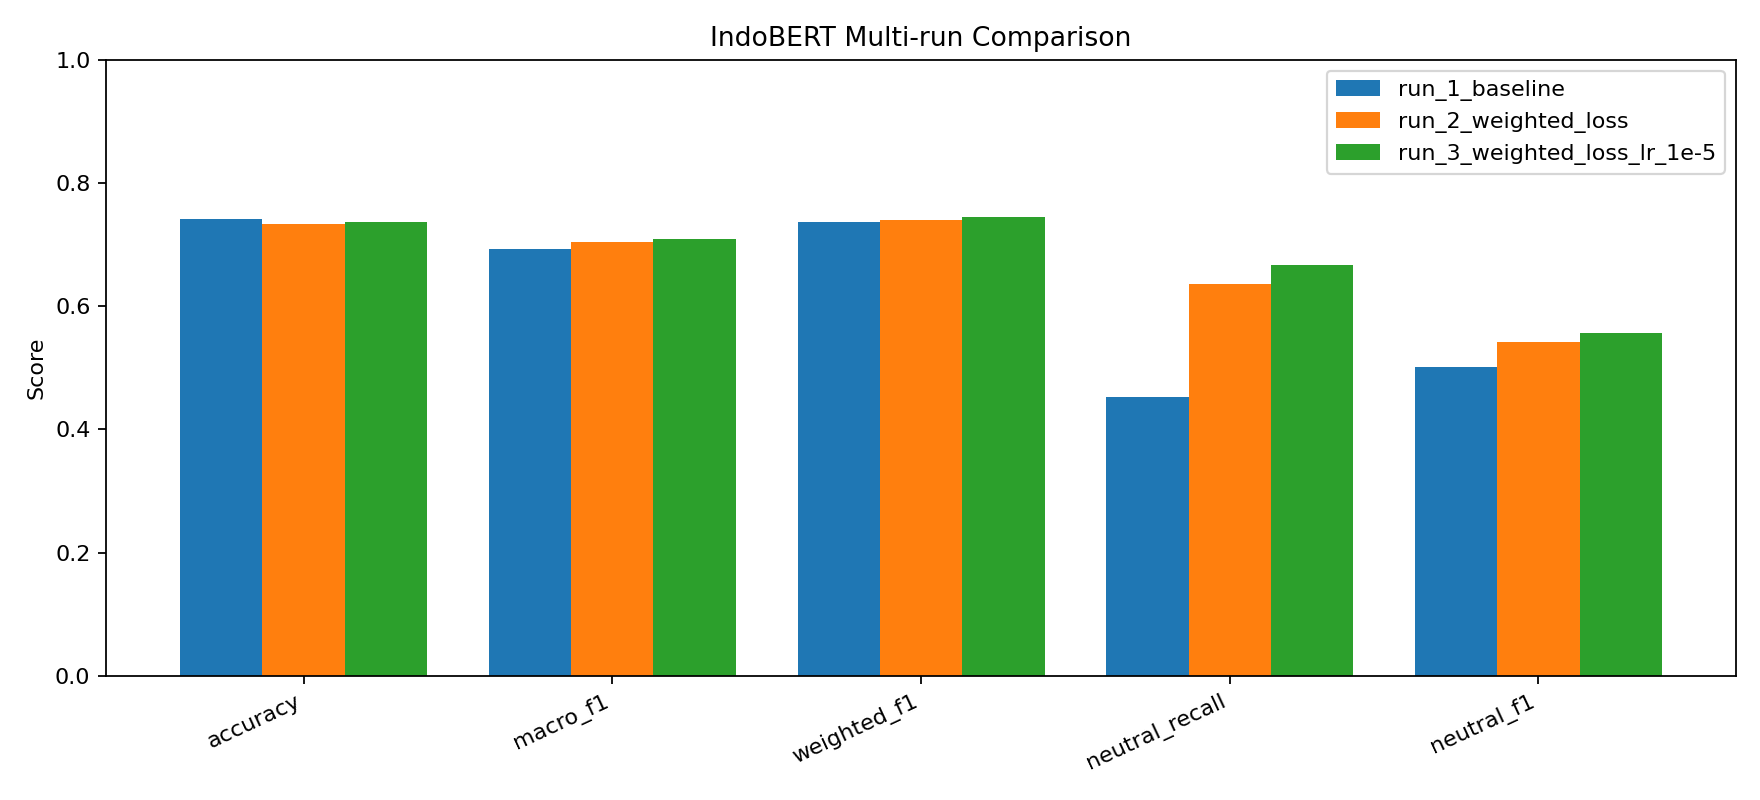

Missing figure: `docs\figures\03_indobert\run_3_weighted_loss_lr_1e-5\indobert_slang_changed_rows.png`

## Run 4 Slang Normalization

**docs\figures\03_indobert\run_4_weighted_loss_lr_1e-5_slang_norm\indobert_confusion_matrix.png**

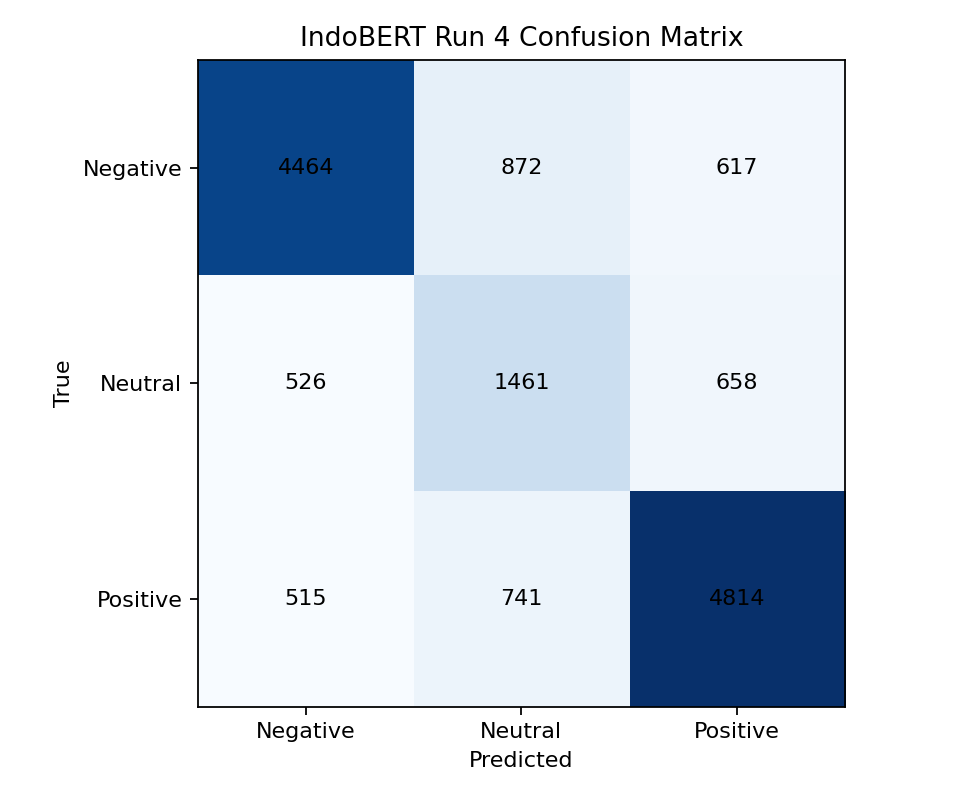

**docs\figures\03_indobert\run_4_weighted_loss_lr_1e-5_slang_norm\indobert_eval_metrics.png**

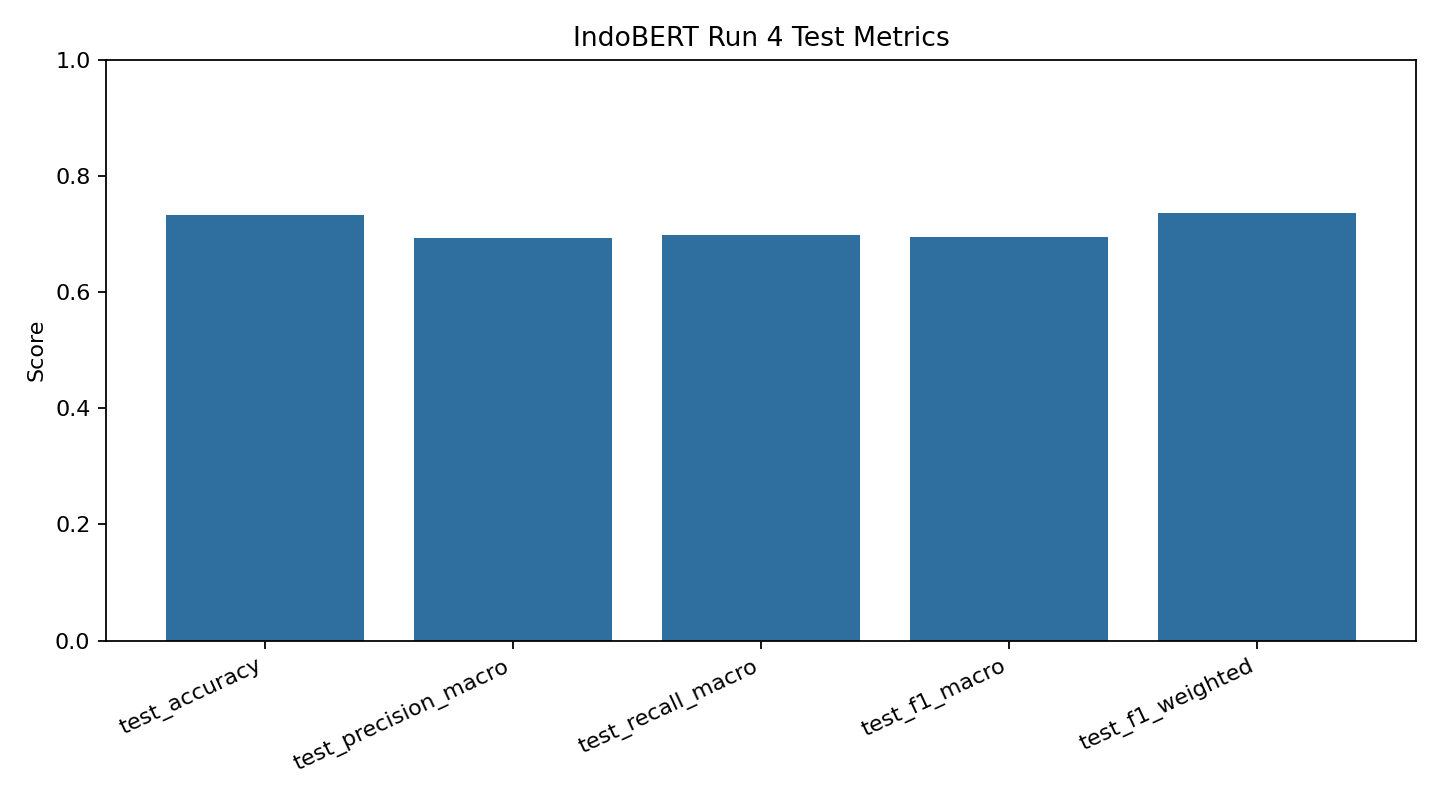

**docs\figures\03_indobert\run_4_weighted_loss_lr_1e-5_slang_norm\indobert_training_loss.png**

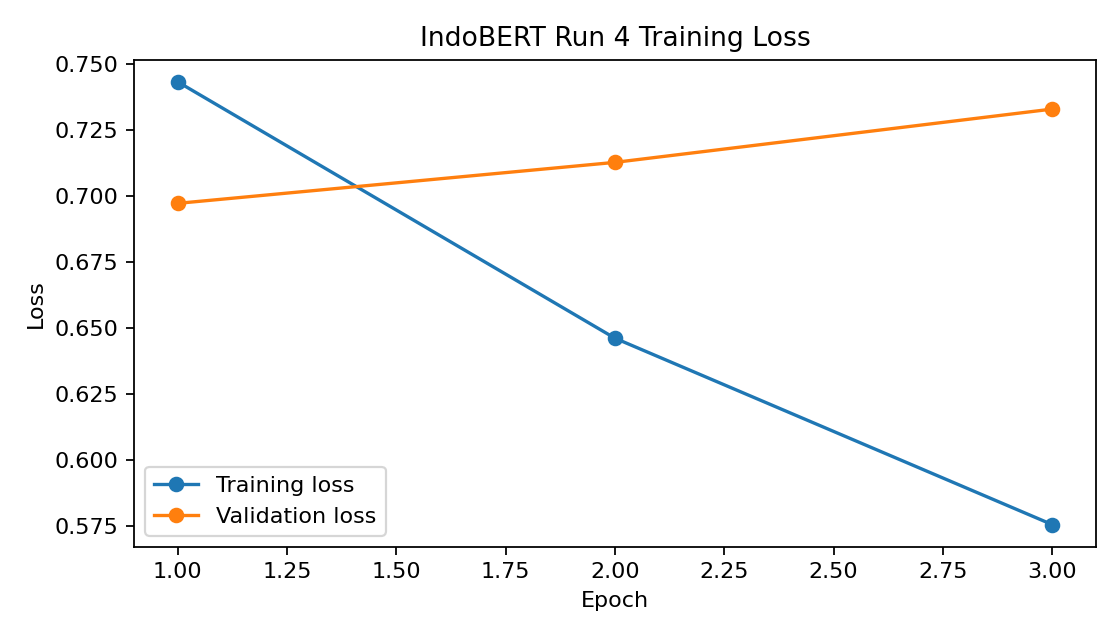

**docs\figures\03_indobert\run_4_weighted_loss_lr_1e-5_slang_norm\indobert_class_f1_score.png**

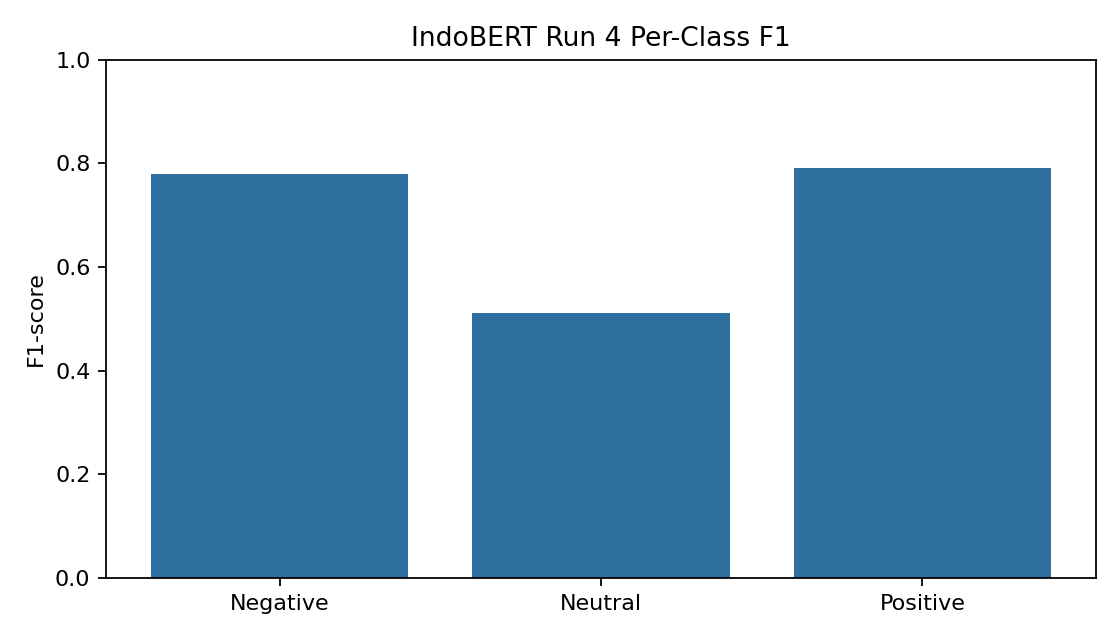

**docs\figures\03_indobert\run_4_weighted_loss_lr_1e-5_slang_norm\indobert_run_comparison.png**

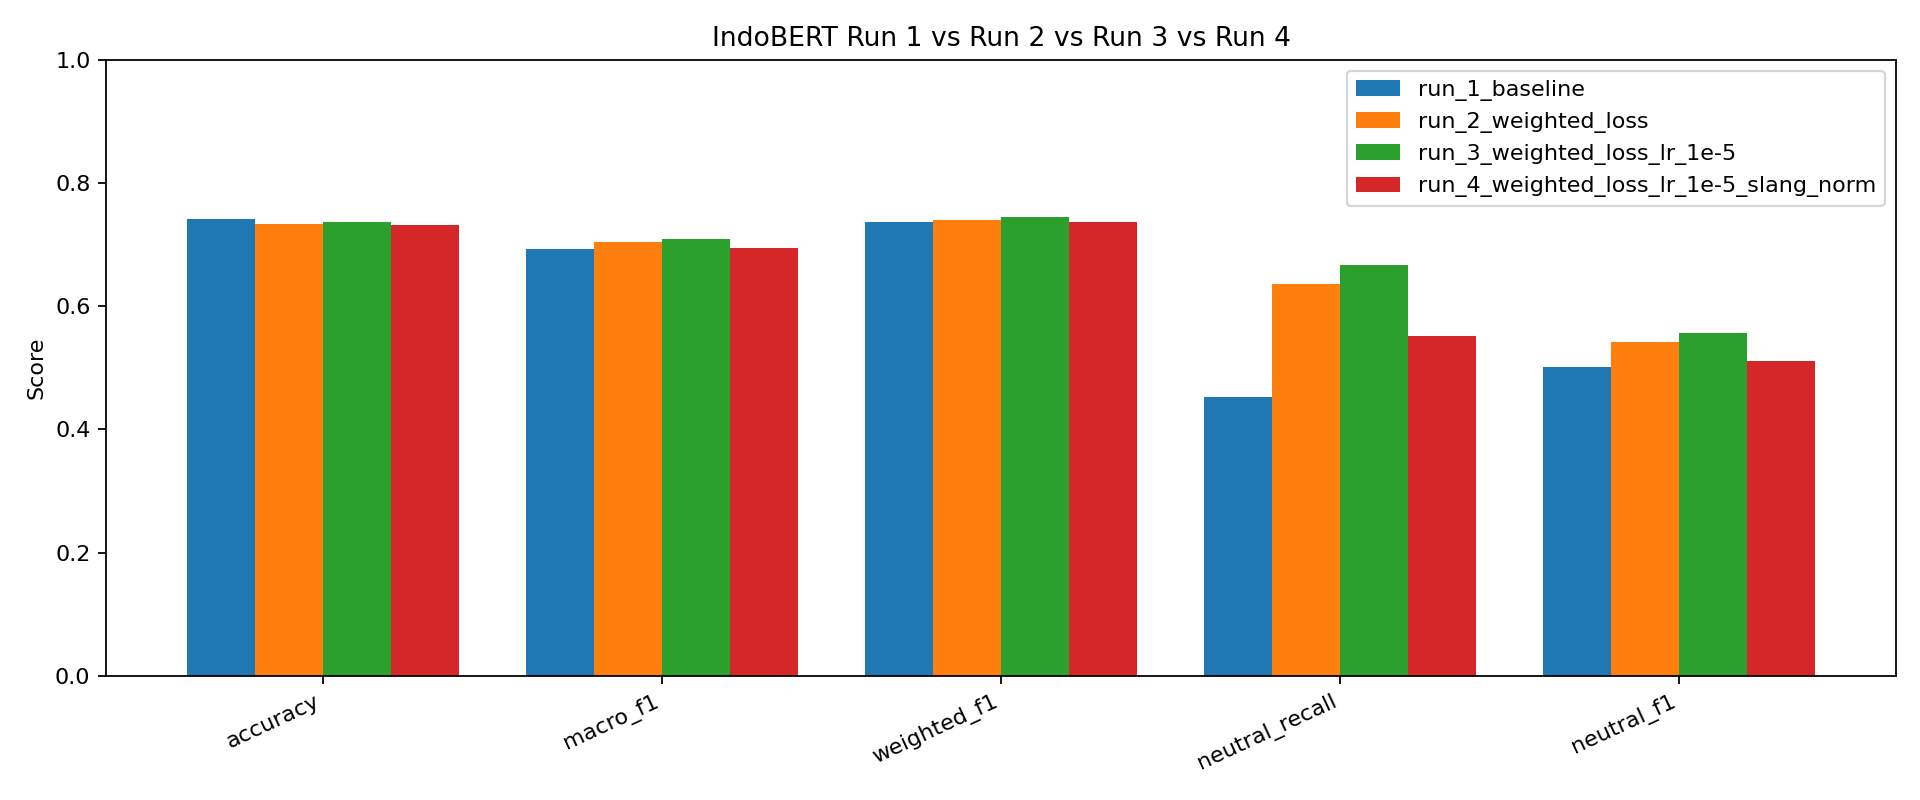

**docs\figures\03_indobert\run_4_weighted_loss_lr_1e-5_slang_norm\indobert_slang_changed_rows.png**

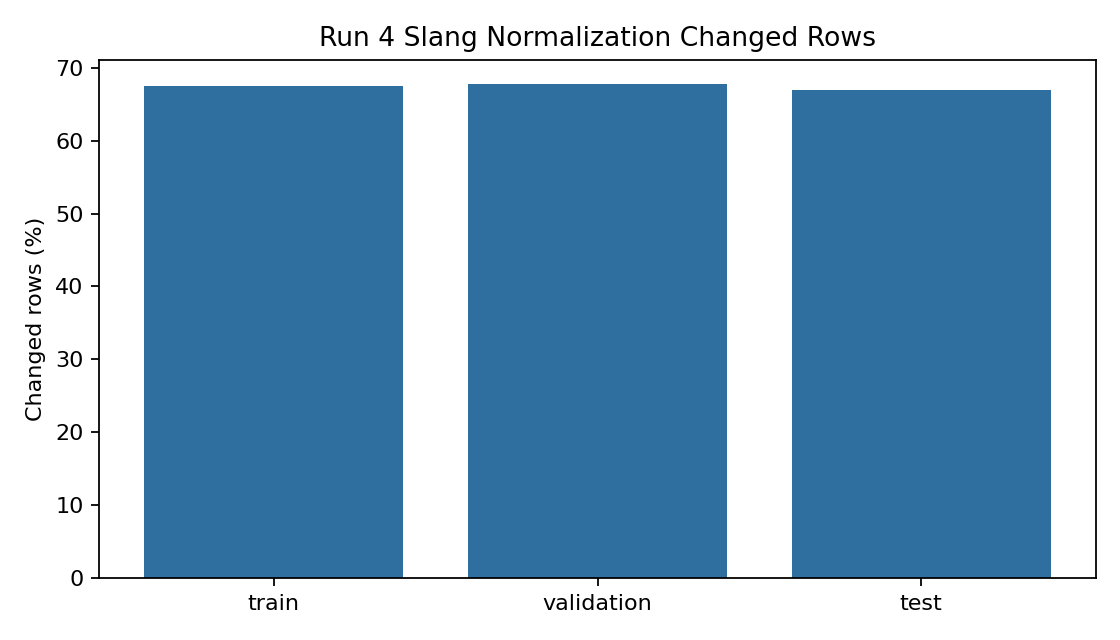

In [5]:
FIG03_DIR = DOCS_FIGURES_DIR / "03_indobert"
figure_names = [
    "indobert_confusion_matrix.png",
    "indobert_eval_metrics.png",
    "indobert_training_loss.png",
    "indobert_class_f1_score.png",
    "indobert_run_comparison.png",
    "indobert_slang_changed_rows.png",
]

for run_name, run_label in RUNS.items():
    run_figures = [FIG03_DIR / run_name / figure for figure in figure_names]
    show_figures(run_figures, run_label)


## Artifact Policy and Next Step

- Do not commit `saved_model/`, checkpoints, tokenizer/model weights, or large prediction files.
- The selected current final candidate is `run_3_weighted_loss_lr_1e-5`.
- Proceed to `05_model_evaluation.ipynb` for final model evaluation documentation and later integrate SVM results after aspect-label quality control.
